In [ ]:
from langgraph.graph import StateGraph, START,END
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from typing import TypedDict, Annotated, Literal
from operator import add
from langsmith import traceable
import os
from dotenv import load_dotenv

from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun, 
from langgraph.prebuilt import ToolNode, tools_condition
import requests


In [36]:
#!pip install langchain-community
# !pip install -U ddgs

In [37]:
class StateSchema(TypedDict):
    messages: Annotated[list[BaseMessage], add]

In [38]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    temperature=0.6
)


# Tools

In [70]:
# prebuild tool
search_tool = DuckDuckGoSearchRun(region="us-en")

# user define tool
@tool
def calculator(num1: int, num2: int, operation: str ) -> int:
    """
    this tool will calculate the sum of numbers
    Input:
        num1: first number
        num2: second number
        operation: type of operation ["sum", "multiply", "divide", "substract"]
    Output:
        int # output of calculation
    """
    output = 0
    if operation == 'sum':
        output = num1+num2
    elif operation == 'multiply':
        output = num1*num2
    elif operation == 'divide':
        output = num1/num2
    else:
        output = num1 - num2
    return output


@tool
def get_university_list(university: str = None, country: str = None):
    """
    fetch the list of universities in different country
    input:
        university[optional]: A word which includes in University Name or full University name
        Country[Optional]: Name of the Country
    """
    params = ""
    if country:
        params += f"country={country}"
    if university:
        if params != "":
            params += "&"
        params += f"name={university}"
    url = f"http://universities.hipolabs.com/search?{params}"
    output = requests.get(url)

    return output.json()
    


In [71]:
# make tools list 
tools = [search_tool, calculator, get_university_list]

# make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [72]:
@traceable(name = "llm_chat_node")
def llm_node(state: StateSchema):
    chats = state["messages"]

    resp = llm_with_tools.invoke(chats)

    return {
        "messages": [resp]
    }

# create tool node
tool_node = ToolNode(tools)


In [73]:
# conn = sqlite3.connect(database = 'chatbot.db', check_same_thread = False)

# checkpointer = SqliteSaver(conn=conn)

In [83]:
graph = StateGraph(StateSchema)\
    .add_node("llm_chat_bot", llm_node)\
    .add_node("tools", tool_node)

In [84]:
graph.add_edge(START, "llm_chat_bot")

graph.add_conditional_edges("llm_chat_bot", tools_condition)
graph.add_edge("tools", "llm_chat_bot")



In [85]:
workflow = graph.compile()


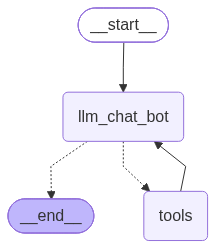

In [86]:
workflow

In [91]:
CONFIG = None

while True:
    msg = input()

    if msg is None:
        continue
    elif msg.lower() in ["exit", "done", "stop", "bye"]:
        break

    initial_message = {"messages": [HumanMessage(content=msg)]}
    resp = workflow.invoke(initial_message)


    print("\nUser: ", msg)

    print("AI: ", resp["messages"][-2])






User:  sum of 3 and 4
AI:  content='7' name='calculator' tool_call_id='call_1008078'


/home/bhavin/workspace/langgraph-practice/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3157: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


ValueError: contents are required.

In [65]:
get_university_list("raipur","india")

[]

In [68]:
requests.get("http://universities.hipolabs.com/search?name=Raipur&country=India").json()

[{'state-province': 'Chhattisgarh',
  'name': 'Hidayatullah National Law University, Raipur',
  'domains': ['hnluraipur.com'],
  'alpha_two_code': 'IN',
  'web_pages': ['http://www.hnluraipur.com/'],
  'country': 'India'},
 {'state-province': 'Chhattisgarh',
  'name': 'ICFAI University, Raipur',
  'domains': ['iuraipur.edu.in'],
  'alpha_two_code': 'IN',
  'web_pages': ['https://www.iuraipur.edu.in/'],
  'country': 'India'},
 {'state-province': 'Chhattisgarh',
  'name': 'National Institute of Technology Raipur',
  'domains': ['nitrr.ac.in'],
  'alpha_two_code': 'IN',
  'web_pages': ['http://www.nitrr.ac.in/'],
  'country': 'India'}]